# 02 — Animal Comparison

Expert (uniform) psychometric for an example WT vs HET, broken down by session / trial condition.

## Setup

In [1]:
%matplotlib inline
from shared_setup import *
from analysis.phase import Phase, calculate_phase

experiment, info = load_data()
print(f"Mode: {info['mode']}")

Loaded snapshot: 22 animals, 1185 sessions (exported 2026-06-09)
Mode: snapshot


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:193: UserWarning: Snapshot is 169h old (exported 2026-06-09T12:49:35.485965+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(


## Genotype groups

In [2]:
# WT = light-delivery controls; HET = active-inhibition opto animals.
# SS01-13 are HETs that predate the opto cohort, so they're excluded from the opto HET group.
NON_OPTO_IDS = ['SS01', 'SS02', 'SS03', 'SS04', 'SS05', 'SS06',
                'SS07', 'SS08', 'SS09', 'SS10', 'SS11', 'SS12', 'SS13']

WT_IDS, HET_IDS = [], []
for animal_id in experiment.animal_ids:
    genotype = experiment.get_animal(animal_id).genotype.upper()
    if genotype == 'WT':
        WT_IDS.append(animal_id)
    elif genotype == 'HET' and animal_id not in NON_OPTO_IDS:
        HET_IDS.append(animal_id)

print(f"WT:  {WT_IDS}")
print(f"HET: {HET_IDS}")

WT:  ['SS14', 'SS17', 'SS18', 'SS20']
HET: ['SS15', 'SS16', 'SS19', 'SS21', 'SS22', 'SS23']


In [3]:
wt_animal = experiment.get_animal(WT_IDS[0])
het_animal = experiment.get_animal(HET_IDS[0])
print(f"WT  {wt_animal.animal_id} ({wt_animal.genotype})")
print(f"HET {het_animal.animal_id} ({het_animal.genotype})")

WT  SS14 (wt)
HET SS15 (het)


## Uniform (expert) — compute per condition

`calculate_phase` fills the `Phase` objects in place, so build a fresh list per animal
(otherwise the two animals would share — and overwrite — the same objects).

In [6]:
def uniform_phases():
    return [
        Phase('uniform_training_last5', 'all',       'Last5 Sessions',    'C0'),
        Phase('uniform_masking',        'all',       'Masking Sessions',  'C1'),
        Phase('uniform_opto',           'all',       'Opto Sessions',     'C2'),
        Phase('uniform_opto',           'non_opto',  'Non-Opto Trials',   'C3'),
        Phase('uniform_opto',           'opto',      'Opto Trials',       'C4'),
        Phase('uniform_opto',           'post_opto', 'Post-Opto Trials',  'C5'),
    ]

wt_phases = uniform_phases()
het_phases = uniform_phases()
wt_results = calculate_phase(wt_animal,  wt_phases,  min_accuracy=0.6, min_trials=10)
het_results = calculate_phase(het_animal, het_phases, min_accuracy=0.6, min_trials=10)

## Compare one condition: WT vs HET

Change `i` to step through conditions. A phase with no surviving sessions has
`psyc_fit is None` — skip those.

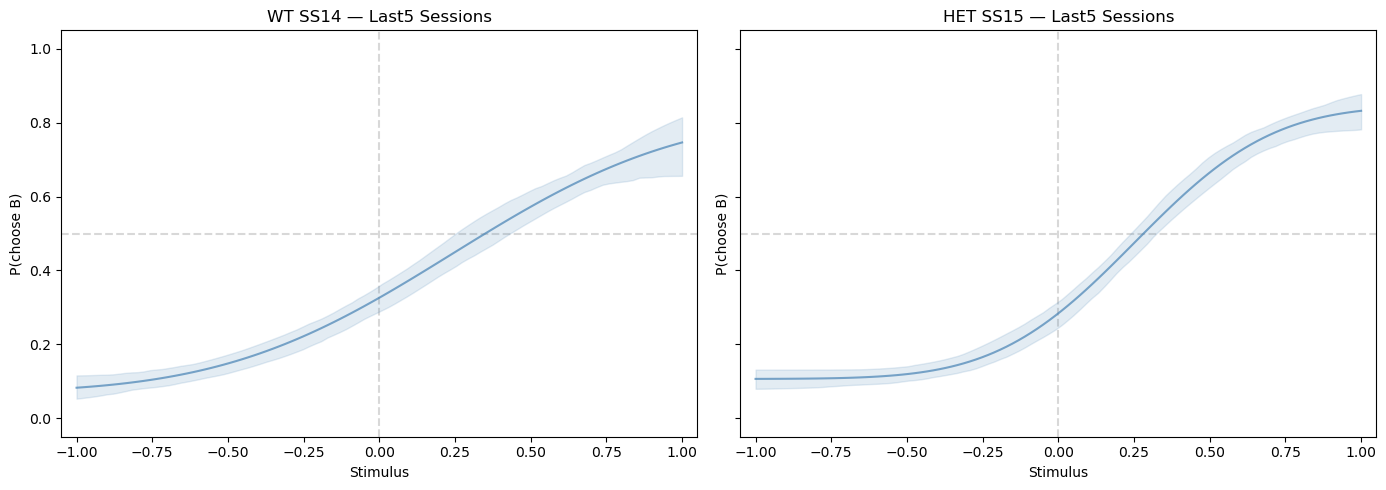

In [5]:
i = 0   # which condition (index into uniform_phases)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_psychometric(wt_phases[i].psyc_fit,  ax=axes[0])
plot_psychometric(het_phases[i].psyc_fit, ax=axes[1])
axes[0].set_title(f"WT {wt_animal.animal_id} — {wt_phases[i].label}")
axes[1].set_title(f"HET {het_animal.animal_id} — {het_phases[i].label}")
plt.tight_layout(); plt.show()